# NLP with Python: The Little Prince

The Little Prince by Antoine De Saint Exupery, has been a book I have loved since I was a child. I wanted to incorporate one of my favorite books into an indepth data science project focuses on machine learning, visualization, and data science. 

-----------

In this notebook I have demonstrated and explanation of each topic listed below.

1. Data Preparation
2. Emotional Arc Line Plot
3. Changepoint Detection
4. Topic Modeling Visualization
5. Character Co-Occurance Network Graph
6. Regression Models

---------

These are the libraries and imports I have used in this notebook.

In [52]:
import csv
import string

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
import ruptures as rpt
from collections import Counter
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

-----

### Data preparation:

I have converted the pdf of The Little Prince into a csv file and cleaned the text to make it more readible.

*For copyright compliance, the full text is not included directly in this notebook and is instead loaded locally as a private file.*

In [3]:
prince_text = []

with open('TheLittlePrince.csv', mode='r') as file:
    princeFile = csv.reader(file)
    
    for row in princeFile:
        if not row:
            continue
        
        line = row[0]           
        line = line.strip()     
        
        stripped = line.lstrip(string.punctuation + " ")
        
        if stripped and stripped[0].isalpha():
            prince_text.append(stripped)

In [4]:
print(prince_text[:10])

['The Little Prince', 'written and illustrated by', 'Antoine de Saint ExupÃ©ry', 'translated from the French by Katherine Woods!', 'The Little Prince', 'written and illustrated by', 'Antoine de Saint ExupÃ©ry', 'translated from the French by Katherine Woods', 'TO LEON WERTH', 'I ask the indulgence of the children who may read this book for dedicating it to a grown-']


In [5]:
full_text = " ".join(prince_text)

I converted the texts into tokens(units)and made them into a dataframe to use for my machine learning models.

In [6]:
prince_sentences = nltk.sent_tokenize(full_text)
df_prince = pd.DataFrame(prince_sentences)

In [7]:
print(df_prince[:5])

                                                   0
0  The Little Prince written and illustrated by A...
1  The Little Prince written and illustrated by A...
2  I have a serious reason: he is the best friend...
3  I have another reason: this grown-up understan...
4  I have a third reason: he lives in France wher...


In [8]:
df_prince = pd.DataFrame(prince_sentences, columns=['text'])

---------

### Emotional Arc Line Plot

#### In this section I have categorized scores which shows sentence-level sentiment over the course of the story. The emotional arc line plot shows the flucations in sentiment, highlighting key narritve elements. 

In this function I scored and categorized each sentence of the book to determine if it was negative, positive, neutrals, and
their compounded score. I added new columns with the results from the function and renamed the columns.

In [9]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    scores = analyzer.polarity_scores(text)
    return pd.Series({
        'negative':scores['neg'],
        'positive':scores['pos'],
        'neutral':scores['neu'],
        'compound':scores['compound']
    })

df_prince[['negative', 'positive', 'neutral', 'compound']]= df_prince['text'].apply(get_sentiment_score)
display(df_prince.head())

,text,negative,positive,neutral,compound
0,The Little Prince written and illustrated by A...,0.000,0.000,1.000,0.0000
1,The Little Prince written and illustrated by A...,0.000,0.000,1.000,0.0000
2,I have a serious reason: he is the best friend...,0.073,0.418,0.508,0.7964
3,I have another reason: this grown-up understan...,0.000,0.000,1.000,0.0000
4,I have a third reason: he lives in France wher...,0.000,0.000,1.000,0.0000


To have an X axis on my plot I needed to create a sentence number column.

In [10]:
df_prince['sentence_num'] = range(1, len(df_prince)+1)

In [11]:
df_prince.head()

,text,negative,positive,neutral,compound,sentence_num
0,The Little Prince written and illustrated by A...,0.000,0.000,1.000,0.0000,1
1,The Little Prince written and illustrated by A...,0.000,0.000,1.000,0.0000,2
2,I have a serious reason: he is the best friend...,0.073,0.418,0.508,0.7964,3
3,I have another reason: this grown-up understan...,0.000,0.000,1.000,0.0000,4
4,I have a third reason: he lives in France wher...,0.000,0.000,1.000,0.0000,5


I condensed the sentences into groups of 50 sections to make the lines more visable on the graph.

In [12]:
df_prince['neg_smooth'] = df_prince['negative'].rolling(window=50).mean()
df_prince['pos_smooth'] = df_prince['positive'].rolling(window=50).mean()

In [13]:
df_prince['chunk'] = df_prince.index // 50

chunked = df_prince.groupby('chunk')[['positive', 'negative']].mean()

<Figure size 1200x600 with 0 Axes>

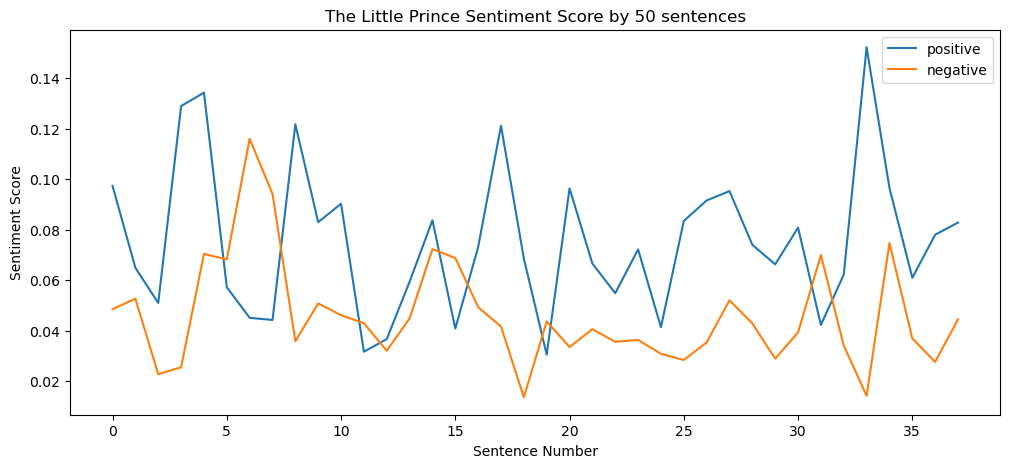

In [14]:
plt.figure(figsize=(12, 6))

chunked.plot(figsize=(12,5))
plt.title("The Little Prince Sentiment Score by 50 sentences")
plt.xlabel('Sentence Number')
plt.ylabel('Sentiment Score')
plt.show()

In this line chart the postive sentiment scores is higher then the negative scores throughout the story. The highest postive
score was above 0.14 between sentene number 30-35.

### Topic Modeling Visualization

#### I computed the length of sentences, words, unique word ratio, and readilibity score (lexical features) to create a line chart for Topic Modeling Visulization.

In [15]:
def lexical_features(sentence):
    if not isinstance(sentence, str):
        sentence = str(sentence)

    words = sentence.split()

    if len(words) == 0:
        return pd.Series({
            'sentence_length': 0,
            'avg_word_length': 0,
            'unique_ratio': 0,
            'readability': 0
        })

    sentence_length = len(words)
    avg_word_length = sum(len(w) for w in words) / len(words)
    unique_ratio = len(set(words)) / len(words)
    readability = textstat.flesch_reading_ease(sentence)

    return pd.Series({
        'sentence_length': sentence_length,
        'avg_word_length': avg_word_length,
        'unique_ratio': unique_ratio,
        'readability': readability
    })

df_prince[['sentence_length','avg_word_length','unique_ratio','readability']] = (
    df_prince['text'].apply(lexical_features)
)


Like the previous chart I have grouped sentences into 50 sections for an easier visual layout.

In [16]:
df_prince['chunked_sentence'] = df_prince.index // 50

chunked_sentence = df_prince.groupby('chunk')[['sentence_length', 'avg_word_length', 'readability']].mean()

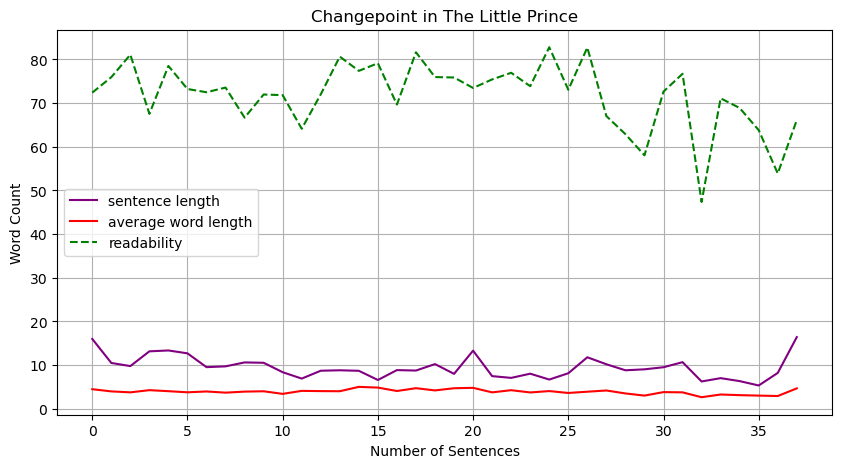

In [17]:
plt.figure(figsize = (10, 5))
plt.plot(chunked_sentence['sentence_length'], color='purple' ,label= 'sentence length')
plt.plot(chunked_sentence['avg_word_length'], color='red', label='average word length')
plt.plot(chunked_sentence['readability'], color = 'green', linestyle ='--' ,label = 'readability')
plt.title('Changepoint in The Little Prince')
plt.xlabel('Number of Sentences')
plt.ylabel('Word Count')
plt.grid()
plt.legend()

In the changepoint chart the average readablity is around 70-80 words, with the lowest reaching around 48. The average sentence
length is around 7-15. Also, the readablity is in a high range between 70-80, with the lowest. Also, the average word length is
around 5 words.

### Character and Word Co-Occurance Network Graph

#### In this section I have created two wordbubble charts that calculated the amount of words that reoccur in the book. The word appears bigger as more frequently it appears in the book. Word bubble charts visualizes the term through the size and color.

In [18]:
prince_lower = [sentence.lower() for sentence in prince_sentences]

In [19]:
type(prince_lower)

list

I listed out the characters in the book and counted how many times they occured in the book. 

In [20]:
characters =["prince", "rose", "fox", "king", "pilot", "snake"]

counts = Counter()

def prince_characters():
    for sentence in prince_lower:
        for name in characters:
            if name in sentence:
                counts[name]+= 1
    return counts
        

In [21]:
char_counts = prince_characters()
print(char_counts)

Counter({'prince': 187, 'king': 79, 'fox': 34, 'rose': 22, 'snake': 17, 'pilot': 1})


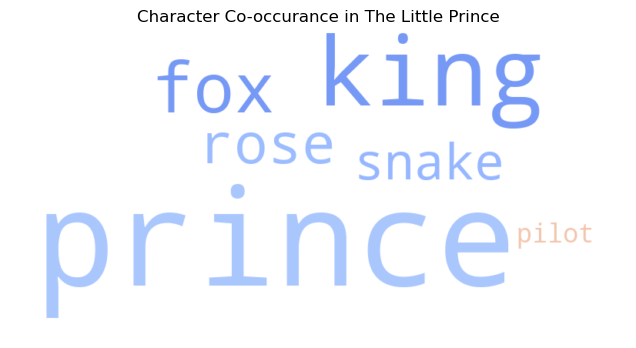

In [28]:
wordcloud = WordCloud(width=800, height=400,
background_color="white", colormap="coolwarm").generate_from_frequencies(char_counts)

plt.figure(figsize =(10,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Character Co-occurance in The Little Prince")
plt.show()

The results show the Prince occured the most frequent in the story. Since the Prince is the main character of the story the results align.

I recleaned the dataframe to create a chart to show what words occur the most in the story.

In [23]:
text = ' '.join(df_prince["text"].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

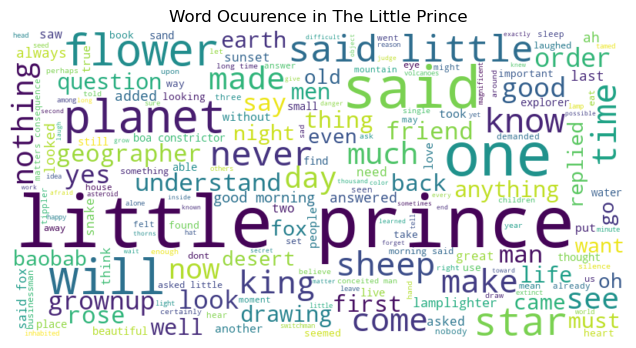

In [27]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Word Ocuurence in The Little Prince")
plt.show()

In this result we have notice besides the little prince, said, one, planet and will occcured the most frequent in the book. 

-------------

### Regression Model Visualization

#### Built regression models to predict sentence-level sentiment from lexical and thematic features, analyzing feature importance and validating relationships statiscally. 

In [53]:
sia = SentimentIntensityAnalyzer()
df_prince2['polarity'] = df_prince2['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_prince2.head()

,text,polarity
0,The Little Prince,0.0
1,written and illustrated by,0.0
2,Antoine de Saint ExupÃ©ry,0.0
3,translated from the French by Katherine Woods!,0.0
4,The Little Prince,0.0


In [55]:
def clean_text(row):
    return str(row['text']).lower()

df_prince2['clean_text'] = df_prince2.apply(clean_text, axis=1)
print(df_prince2[['text', 'clean_text']].head())

                                             text  \
0                               The Little Prince   
1                      written and illustrated by   
2                       Antoine de Saint ExupÃ©ry   
3  translated from the French by Katherine Woods!   
4                               The Little Prince   

                                       clean_text  
0                               the little prince  
1                      written and illustrated by  
2                       antoine de saint exupã©ry  
3  translated from the french by katherine woods!  
4                               the little prince  


I measured the polarity scores into binary labels in the dataframe. The range is from -1(negative) to +1(positive).

In [63]:
df_prince2['label'] = np.where(df_prince2['polarity'] > 0, 1, 0)

Then I test, train, and split the clean text and polarity scores. 

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
        df_prince2['clean_text'],
        df_prince2['polarity'],
        test_size=0.2,
        random_state=42
)

print("Train size:", len(X_train))
print("test size:", len(X_test))

Train size: 1018
test size: 255


Then I vectorize the text into numbers so the models can understand it. The TfidVectorizer counts the weighed importance of words.

In [65]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (1018, 5000)
TF-IDF shape (test): (255, 5000)


The Bernoulli Naive Bayes (BernouliNB) predicts the sentiment polarity of sentences. The model converts each sentence into a binary vector of word presence/absence and predicts whether the sentiment is positive or negative. The Performance is shown through precision, recall, and F1- score.

In [70]:
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train_binary)

bnb_pred = bnb.predict(X_test_tfidf)

print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test_binary, bnb_pred))
print("\nBernoulliNB Classification Report:\n", classification_report(y_test_binary, bnb_pred))

Bernoulli Naive Bayes Accuracy: 0.7058823529411765

BernoulliNB Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.99      0.81       166
           1       0.94      0.17      0.29        89

    accuracy                           0.71       255
   macro avg       0.81      0.58      0.55       255
weighted avg       0.78      0.71      0.63       255



In the BernoulliNB model, had an overall accuracy of 0.71. With a high recall of 0.99, the model accurately predicts negative/neutral sentences (label 0), meaning it hardly ever misses negative/neutral sentiment. However, it has trouble with positive sentences (label 1), and as a result, many positive sentences are miclassified as negative or neutral, with a recall of only 0.17. The F1-scores demonstrate this, with positive sentences scoring only 0.29 and negative/neutral sentences scoring 0.81.

In [73]:
svm = LinearSVC(max_iter=1000)
svm.fit(X_train_tfidf, y_train_binary)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test_binary, svm_pred))
print("\nSVM Classification Report:\n", classification_report(y_test_binary, svm_pred))

SVM Accuracy: 0.7490196078431373

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.82       166
           1       0.67      0.56      0.61        89

    accuracy                           0.75       255
   macro avg       0.72      0.71      0.71       255
weighted avg       0.74      0.75      0.74       255



C:\Users\ginat\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In the SVM model, it had an overall accuracy of 0.73. With a precision of 0.78 and recall of 0.85, the model accurately predicts the majority of negative/neutral sentences (label 0). With a precision of 0.67 and recall of 0.56, positive sentences (label 1) are predicted more accurately than in BernoulliNB, but they are still somewhat missed. The F1-scores, which show a more balanced performance across the two classes, reflect this, with negative/neutral scores of 0.82 and positive sentences of 0.61.

In [74]:
logreg = LogisticRegression(max_iter=100)
logreg.fit(X_train_tfidf, y_train_binary)

logreg_pred = logreg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test_binary, logreg_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test_binary, logreg_pred))

Logistic Regression Accuracy: 0.7333333333333333

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.99      0.83       166
           1       0.92      0.26      0.40        89

    accuracy                           0.73       255
   macro avg       0.82      0.62      0.62       255
weighted avg       0.79      0.73      0.68       255



In the Logistic Regression model, it had and overall accuracy of 0.73. It performs well on negative/neutral sentences (label 0) with a high recall value of 0.99, implying that almost all negative/neutral sentences are identified as such. It performs poorly on positive sentences (label 1), with a recall value of 0.26, implying that many positive sentences are identified as negative/neutral. This is brought to light by the F1-scores obtained for negative/neutral sentences, which is 0.83, but for positive sentences, it is 0.40.

Overall, among all three models, SVM performed best with 75% acccuracy and the most balanced prediction across negative/neutral and postive sentence, resulted in the most reliable for sentence-level sentiment classification.

----------

### Conclusion

#### This project taught me how to clean and analyze textual data, apply sentiment analysis, track emotional arcs, model topics, and compare machine learning models for text classification. I also gained experience in visualizing results and interpreting patterns, reinforcing my ability to turn unstructured text into actionable insights.